# **Credit Card Fraud Detection Using Machine Learning**

## Project Summary

This project focuses on developing a Machine Learning-based Credit Card Fraud Detection System that can identify whether a transaction is genuine or fraudulent. The dataset contains 32,300 transactions and 10 attributes, including transaction amount, account balance, transaction frequency, transaction hour, merchant risk score, and previous fraud information. Various classification algorithms such as Logistic Regression, Decision Tree, SVM, KNN, Gradient Boosting, and Bagging are evaluated using metrics such as Accuracy, Precision, Recall, F1 Score, and ROC-AUC. Gradient Boosting is further tuned using RandomizedSearchCV to improve classification performance.

## Project Objectives

To analyze credit card transaction data and identify fraud-related patterns.
To perform Exploratory Data Analysis (EDA) on transaction characteristics.
To understand the differences between fraudulent and genuine transactions.
To identify important factors associated with fraudulent transactions.
To preprocess the dataset and prepare features for machine learning.
To develop multiple classification models for fraud detection.
To compare model performance using Accuracy, Precision, Recall, F1 Score, and ROC-AUC.
To optimize the Gradient Boosting Classifier using hyperparameter tuning.
To evaluate the final model using a confusion matrix.
To analyze feature importance and identify influential fraud indicators.
To build a reliable model that can help detect potentially fraudulent transactions.

## Dataset Description

The dataset used for this project contains 32,300 credit card transaction records with 10 attributes. It provides information about customer characteristics, transaction behavior, merchant-related risk, and the final fraud classification. The target variable is_fraud indicates whether a transaction is genuine (0) or fraudulent (1).

## The Dataset Includes the Following Key Attributes:

* age - Age associated with the transaction/customer
* transaction_amount - Monetary amount of the transaction
* account_balance	- Account balance associated with the transaction
* num_transactions_today -Number of transactions made during the day
* is_foreign_transaction- Indicates whether the transaction is foreign or domestic
* transaction_hour -	Hour at which the transaction occurred
* prev_fraud_flag	- Indicates whether there was a previous fraud-related flag
* merchant_distance_km	- Distance between the customer and merchant in kilometers
* merchant_risk_score - 	Risk score associated with the merchant
* is_fraud - Target variable indicating genuine (0) or fraudulent (1) transaction

# Importing The Required Libraries

In [ ]:
import numpy as np
import seaborn as sns
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [ ]:
data=pd.read_csv("/content/drive/MyDrive/Credit Card Fraud Detection Using Machine Learning/Credit Card Fraud Detection.csv", encoding='latin1')
data

,age,transaction_amount,account_balance,num_transactions_today,is_foreign_transaction,transaction_hour,prev_fraud_flag,merchant_distance_km,merchant_risk_score,is_fraud
0,41.0,2453.81,12686.50,21.0,0.0,9.0,0.0,2438.2,5.2,0
1,49.0,1574.12,36337.02,37.0,0.0,4.0,0.0,2967.1,8.4,1
2,38.0,14897.42,23295.64,21.0,0.0,0.0,0.0,4703.6,3.7,0
3,38.0,9927.23,38586.08,46.0,0.0,17.0,0.0,4281.2,5.5,1
4,61.0,12914.13,2013.73,34.0,0.0,NaN,0.0,4366.7,9.7,1
...,...,...,...,...,...,...,...,...,...,...
32295,52.0,7033.85,7657.07,40.0,0.0,6.0,0.0,304.7,8.2,0
32296,48.0,8974.84,22418.91,49.0,0.0,18.0,0.0,3683.3,6.4,1
32297,70.0,5240.01,43444.14,41.0,0.0,9.0,0.0,3836.7,5.1,0
32298,28.0,8717.43,12451.13,11.0,0.0,0.0,0.0,1620.7,9.4,0


In [ ]:
df=data.copy()

# Data Understanding

In [ ]:
df.head()

,age,transaction_amount,account_balance,num_transactions_today,is_foreign_transaction,transaction_hour,prev_fraud_flag,merchant_distance_km,merchant_risk_score,is_fraud
0,41.0,2453.81,12686.50,21.0,0.0,9.0,0.0,2438.2,5.2,0
1,49.0,1574.12,36337.02,37.0,0.0,4.0,0.0,2967.1,8.4,1
2,38.0,14897.42,23295.64,21.0,0.0,0.0,0.0,4703.6,3.7,0
3,38.0,9927.23,38586.08,46.0,0.0,17.0,0.0,4281.2,5.5,1
4,61.0,12914.13,2013.73,34.0,0.0,NaN,0.0,4366.7,9.7,1


In [ ]:
df.tail()

,age,transaction_amount,account_balance,num_transactions_today,is_foreign_transaction,transaction_hour,prev_fraud_flag,merchant_distance_km,merchant_risk_score,is_fraud
32295,52.0,7033.85,7657.07,40.0,0.0,6.0,0.0,304.7,8.2,0
32296,48.0,8974.84,22418.91,49.0,0.0,18.0,0.0,3683.3,6.4,1
32297,70.0,5240.01,43444.14,41.0,0.0,9.0,0.0,3836.7,5.1,0
32298,28.0,8717.43,12451.13,11.0,0.0,0.0,0.0,1620.7,9.4,0
32299,66.0,10614.83,27752.37,18.0,0.0,11.0,0.0,4753.6,3.2,0


In [ ]:
df.shape

(32300, 10)

In [ ]:
df.columns

Index(['age', 'transaction_amount', 'account_balance',
       'num_transactions_today', 'is_foreign_transaction', 'transaction_hour',
       'prev_fraud_flag', 'merchant_distance_km', 'merchant_risk_score',
       'is_fraud'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32300 entries, 0 to 32299
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   age                     31656 non-null  object 
 1   transaction_amount      31653 non-null  float64
 2   account_balance         31655 non-null  float64
 3   num_transactions_today  31654 non-null  float64
 4   is_foreign_transaction  31649 non-null  float64
 5   transaction_hour        31657 non-null  float64
 6   prev_fraud_flag         31654 non-null  float64
 7   merchant_distance_km    31657 non-null  float64
 8   merchant_risk_score     31656 non-null  float64
 9   is_fraud                32300 non-null  int64  
dtypes: float64(8), int64(1), object(1)
memory usage: 2.5+ MB


In [ ]:
df.isnull().sum()

,0
age,644
transaction_amount,647
account_balance,645
num_transactions_today,646
is_foreign_transaction,651
transaction_hour,643
prev_fraud_flag,646
merchant_distance_km,643
merchant_risk_score,644
is_fraud,0


In [ ]:
df.duplicated().sum()

np.int64(298)

In [ ]:
df.describe()

,transaction_amount,account_balance,num_transactions_today,is_foreign_transaction,transaction_hour,prev_fraud_flag,merchant_distance_km,merchant_risk_score,is_fraud
count,31653.000000,31655.000000,31654.000000,31649.000000,31657.000000,31654.000000,31657.000000,31656.000000,32300.000000
mean,7471.580234,25020.772509,24.924591,0.145818,11.466532,0.081032,2500.266033,5.512513,0.481734
std,4324.127410,14423.748726,14.150679,0.352929,6.920080,0.272889,1444.739723,2.594919,0.499674
min,1.070000,-99999.000000,1.000000,0.000000,0.000000,0.000000,0.100000,1.000000,0.000000
25%,3723.400000,12510.295000,13.000000,0.000000,5.000000,0.000000,1250.000000,3.300000,0.000000
50%,7475.070000,25050.490000,25.000000,0.000000,11.000000,0.000000,2507.000000,5.500000,0.000000
75%,11199.090000,37530.215000,37.000000,0.000000,17.000000,0.000000,3741.300000,7.800000,1.000000
max,14999.710000,49998.900000,49.000000,1.000000,28.000000,1.000000,4999.800000,15.000000,1.000000


# Data Cleaning

In [ ]:
df['age'] = pd.to_numeric(df['age'], errors='coerce')
df.loc[(df['age'] < 0) | (df['age'] > 100), 'age'] = np.nan
df['age'] = df['age'].fillna(df['age'].median())

In [ ]:
df['account_balance'] = df['account_balance'].replace(-99999, np.nan)
df['account_balance'] = df['account_balance'].fillna(df['account_balance'].mean())

In [ ]:
df['transaction_amount'] = df['transaction_amount'].fillna(df['transaction_amount'].mean())
df['num_transactions_today'] = df['num_transactions_today'].fillna(df['num_transactions_today'].mean())
df['transaction_hour'] = df['transaction_hour'].fillna(df['transaction_hour'].mean())
df['merchant_distance_km'] = df['merchant_distance_km'].fillna(df['merchant_distance_km'].mean())
df['merchant_risk_score'] = df['merchant_risk_score'].fillna(df['merchant_risk_score'].mean())

In [ ]:
df['is_foreign_transaction'] = df['is_foreign_transaction'].fillna(df['is_foreign_transaction'].mode()[0])
df['prev_fraud_flag'] = df['prev_fraud_flag'].fillna(df['prev_fraud_flag'].mode()[0])

In [ ]:
df.isnull().sum()

,0
age,0
transaction_amount,0
account_balance,0
num_transactions_today,0
is_foreign_transaction,0
transaction_hour,0
prev_fraud_flag,0
merchant_distance_km,0
merchant_risk_score,0
is_fraud,0


In [ ]:
print("account_balance min after fix:", df['account_balance'].min())
print("age min/max after fix:", df['age'].min(), df['age'].max())

account_balance min after fix: 0.23
age min/max after fix: 18.0 74.0


In [ ]:
df.duplicated().sum()

np.int64(298)

In [ ]:
df = df.drop_duplicates()

In [ ]:
df.duplicated().sum()

np.int64(0)

# Exploratory Data Analysis & Visualization

1.*Fraud vs Genuine Transactions*

In [ ]:
import plotly.express as px

fig = px.bar(
    df['is_fraud'].value_counts().reset_index(),
    x='is_fraud',
    y='count',
    color='is_fraud',
    text='count',
    labels={'is_fraud':'Fraud Status','count':'Number of Transactions'},
    title='Fraud vs Genuine Transactions'
)
fig.show()

Analysis

* The dataset contains 32,002 transactions after data cleaning and duplicate removal.
* 16,590 transactions are genuine, while 15,412 are fraudulent.
* Genuine transactions are slightly higher than fraudulent transactions.
* The two classes are relatively balanced, which is useful for binary classification.
* The high number of fraudulent transactions shows the importance of an effective fraud detection model.


2. *Fraud Distribution*

In [ ]:
fig = px.pie(
    df,
    names='is_fraud',
    title='Fraud Transaction Percentage',
    hole=0.4
)
fig.show()

Analysis

* **Genuine transactions:** 51.8% of the total transactions.
* **Fraudulent transactions:** 48.2% of the total transactions.
* Genuine transactions are **slightly higher** than fraudulent transactions.
* The difference between the two categories is only **3.6 percentage points**.
* This shows that the dataset has a **relatively balanced distribution** between fraud and genuine transactions.
* The considerable proportion of fraudulent transactions indicates a **significant fraud detection problem**.
* Since both classes have sufficient representation, the dataset is suitable for **binary classification using machine learning**.
* The model should focus especially on **correctly detecting fraudulent transactions** while reducing false predictions.


3. *Transaction Amount Distribution*

In [ ]:
fig = px.histogram(
    df,
    x='transaction_amount',
    nbins=50,
    title='Distribution of Transaction Amount',
    marginal='box'
)
fig.show()

Analysis

* The transaction amounts are spread across a **wide range**, approximately from **0 to 15,000**.
* Most transaction amounts are **fairly evenly distributed** across the range.
* There is a noticeable concentration around **7,000–8,000**, where the transaction count is relatively high.
* The distribution does not show a strong **right or left skew**, indicating a relatively balanced spread of transaction values.
* The box plot shows that the **median transaction amount is around 7,500**.
* The middle 50% of transactions are approximately between **4,000 and 11,000**.
* Transaction amounts therefore show **considerable variability** in the dataset.
* This feature can be useful in fraud detection because unusually high or low transaction amounts may indicate **potentially suspicious activity**.


4. *Transaction Amount by Fraud Status*

In [ ]:
import plotly.express as px

fig = px.violin(
    df,
    x='is_fraud',
    y='transaction_amount',
    color='is_fraud',
    box=True,
    points='all',
    title='Transaction Amount Distribution by Fraud Status'
)

fig.show()

Analysis

* **Genuine transactions (0)** show a lower central transaction amount compared with fraudulent transactions.
* **Fraudulent transactions (1)** have a **higher median transaction amount**.
* The fraudulent group is more concentrated toward **higher transaction values**, particularly around **8,000–12,000**.
* Genuine transactions are more widely distributed across the lower and middle transaction-value ranges.
* Both fraud and genuine transactions cover a **broad range of transaction amounts**.
* The distributions overlap considerably, meaning **transaction amount alone cannot determine whether a transaction is fraudulent**.
* However, the higher transaction values observed for fraudulent transactions suggest that **transaction amount is an important feature for fraud prediction**.
* Combining transaction amount with other features such as **merchant risk score, transaction frequency, and previous fraud history** can improve fraud detection.


5. *Account Balance Distribution*

In [ ]:
fig = px.histogram(
    df,
    x='account_balance',
    nbins=50,
    color='is_fraud',
    title='Account Balance Distribution'
)
fig.show()

Analysis

* Account balances are distributed across a **wide range of approximately 0 to 50,000**.
* Both **genuine (0)** and **fraudulent (1)** transactions are present across most balance ranges.
* The distribution is relatively **consistent across the account-balance range**.
* A noticeable peak occurs around **25,000**, where the transaction count is considerably higher.
* The genuine and fraudulent transaction distributions show substantial **overlap**.
* This indicates that **account balance alone may not be a strong indicator of fraud**.
* However, account balance can still contribute to fraud detection when combined with other transaction-related features.
* Overall, the feature shows **wide variability but no clear separation between fraud and genuine transactions**.


6. *Age Distribution by Fraud*

In [ ]:
fig = px.histogram(
    df,
    x='age',
    color='is_fraud',
    nbins=30,
    barmode='group',
    title='Age Distribution by Fraud Status',
    labels={
        'age': 'Age',
        'is_fraud': 'Fraud Status'
    }
)

fig.show()

Analysis

* The age of customers ranges approximately from **18 to 75 years**.
* Both **genuine (0)** and **fraudulent (1)** transactions are present across almost all age groups.
* Fraudulent transactions are relatively higher among **younger age groups**, particularly around the early 20s to 30s.
* From around **50 years onwards**, genuine transactions generally become more frequent than fraudulent transactions.
* The difference between fraud and genuine transactions becomes more noticeable in the **older age groups**.
* Both categories show a noticeable peak around the **mid-40s**.
* The distributions overlap considerably, indicating that **age alone is not sufficient to identify fraudulent transactions**.
* Age can still be used as a supporting feature along with transaction amount, merchant risk score, transaction frequency, and other fraud-related variables.


7. *Merchant Risk Score vs Transaction Amount*

In [ ]:
fig = px.strip(
    df,
    x='is_fraud',
    y='merchant_risk_score',
    color='is_fraud',
    title='Merchant Risk Score by Fraud Status'
)

fig.show()

Analysis

* The **merchant risk score ranges approximately from 1 to 10** for both transaction categories.
* Both genuine (**0**) and fraudulent (**1**) transactions are distributed across almost the **entire risk-score range**.
* Fraudulent transactions show a **slightly stronger presence at higher risk scores**.
* The distribution indicates that merchants with higher risk scores may be **more associated with fraudulent transactions**.
* There is considerable overlap between the two groups, so **merchant risk score alone cannot determine fraud**.
* The chart also shows a **single unusually high value around 15** for a fraudulent transaction, which may be an **outlier**.
* Overall, merchant risk score appears to be a **useful supporting feature** for fraud detection when combined with other transaction characteristics.


8.*Fraud Rate by Transaction Hour*

In [ ]:
fraud_hour = (
    df.groupby('transaction_hour')['is_fraud']
      .mean()
      .reset_index()
)

fig = px.line(
    fraud_hour,
    x='transaction_hour',
    y='is_fraud',
    markers=True,
    title='Fraud Rate by Transaction Hour'
)

fig.show()

Analysis

* The fraud rate varies across different **transaction hours**, showing a clear time-based pattern.
* At the beginning of the day, the fraud rate is around **41%–45%**.
* The fraud rate gradually increases during the day and reaches around **50%** at approximately **8 AM**.
* From around **14:00 onwards**, the fraud rate remains relatively high, mostly above **50%**.
* The highest fraud rate is observed around **23:00**, at approximately **56%**.
* There is a noticeable increase in fraud activity during the **later hours of the day**.
* The sharp drop at the final plotted hour should be interpreted cautiously because it may be due to **very few transactions at that hour**.
* Overall, **transaction hour appears to be an important behavioral feature** that can help the model identify potentially fraudulent transactions.


9. *Foreign Transactions Count*

In [ ]:
fig = px.histogram(
    df,
    x='is_foreign_transaction',
    color='is_fraud',
    barmode='group',
    title='Foreign vs Domestic Transactions'
)
fig.show()

Analysis

* **Domestic transactions (`is_foreign_transaction = 0`)** are much more numerous than foreign transactions.
* Among domestic transactions, **genuine transactions are higher** than fraudulent transactions.
* **Foreign transactions (`is_foreign_transaction = 1`)** have a noticeably higher number of **fraudulent transactions** than genuine transactions.
* This shows a **stronger association between foreign transactions and fraud** in the dataset.
* Although foreign transactions represent a smaller share of total transactions, their fraud count is relatively high.
* Therefore, **foreign transaction status can be an important feature for fraud detection**.
* The model can combine this feature with transaction amount, merchant risk score, transaction hour, and previous fraud history for better prediction.


10. *Merchant Distance vs Fraud*

In [ ]:
fig = px.strip(
    df,
    x='is_fraud',
    y='merchant_distance_km',
    color='is_fraud',
    title='Merchant Distance by Fraud Status'
)

fig.show()

Analysis

* Merchant distance ranges from approximately **0 to 5,000 km** for both genuine and fraudulent transactions.
* Both **genuine (0)** and **fraudulent (1)** transactions are distributed across almost the entire distance range.
* The two groups show **considerable overlap** in merchant distance.
* There is no clear separation between fraudulent and genuine transactions based only on merchant distance.
* This suggests that **merchant distance alone may not be sufficient** to identify fraudulent transactions.
* However, merchant distance can still be a useful feature when combined with other factors such as **transaction amount, merchant risk score, transaction hour, and foreign transaction status**.
* Overall, the feature provides supporting information for the **fraud detection classification model**.


11. *Previous Fraud Flag*

In [ ]:
fig = px.histogram(
    df,
    x='prev_fraud_flag',
    color='is_fraud',
    barmode='group',
    title='Previous Fraud Flag Analysis'
)
fig.show()

Analysis

* Most transactions have **no previous fraud flag (`prev_fraud_flag = 0`)**.
* Among transactions without a previous fraud flag, **genuine transactions are more numerous** than fraudulent transactions.
* For **`prev_fraud_flag = 1`**, fraudulent transactions are significantly higher than genuine transactions.
* This indicates a **strong relationship between previous fraud history and the likelihood of a current fraudulent transaction**.
* Transactions with a previous fraud flag appear to be **more suspicious** and require closer monitoring.
* Therefore, **`prev_fraud_flag` is an important predictive feature** for the fraud detection model.
* Overall, previous fraud history can help the model identify customers or transactions with a **higher risk of fraudulent activity**.


12. *Average Transactions by Fraud Status*

In [ ]:
avg_transactions = (
    df.groupby('is_fraud')['num_transactions_today']
      .mean()
      .reset_index()
)

fig = px.bar(
    avg_transactions,
    x='is_fraud',
    y='num_transactions_today',
    color='is_fraud',
    text_auto='.2f',
    title='Average Number of Transactions by Fraud Status'
)

fig.show()

Analysis

* Genuine transactions have an average of **23.28 transactions per day**.
* Fraudulent transactions have a higher average of **26.69 transactions per day**.
* Fraudulent transactions therefore show approximately **3.41 more transactions per day** on average.
* This indicates that fraudulent activity may be associated with **higher transaction frequency**.
* The higher transaction frequency can be considered a potential indicator of **unusual or suspicious transaction behavior**.
* Therefore, `num_transactions_today` can be an **important feature for fraud detection**.
* However, transaction frequency should be analyzed together with other features for more reliable fraud prediction.


# Outlier Detection

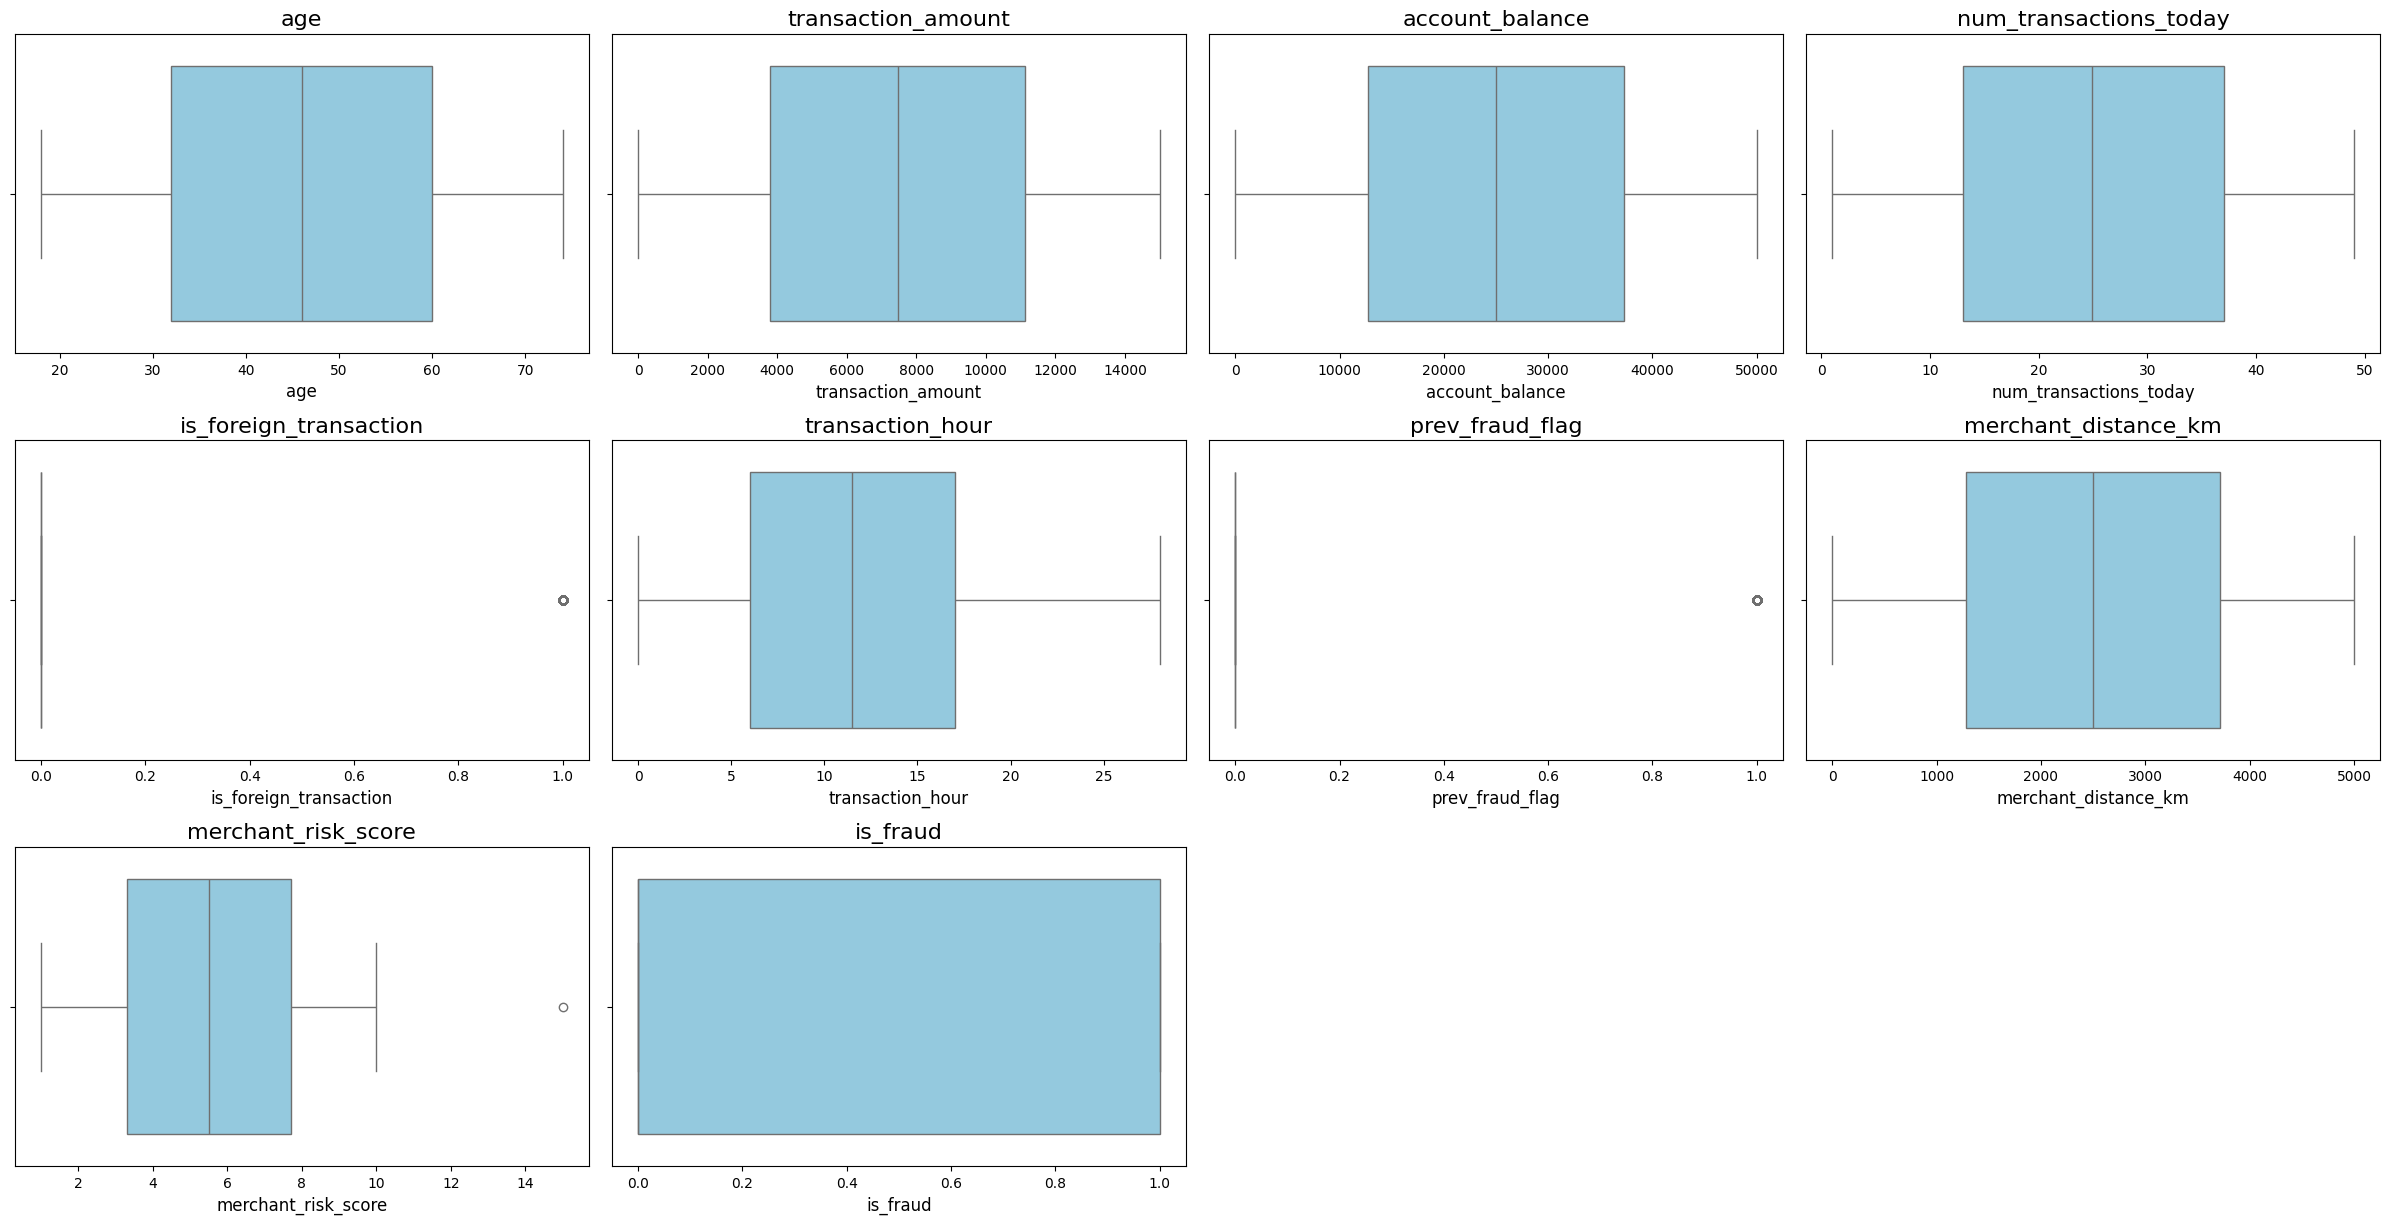

In [ ]:
plt.figure(figsize=(24, 20), facecolor="white")

plotnumber = 1

for column in df.columns[:10]:   # Plot first 10 columns
    plt.subplot(5, 4, plotnumber)
    sns.boxplot(x=df[column], color="skyblue")
    plt.xlabel(column, fontsize=12)
    plt.title(column, fontsize=16)
    plotnumber += 1

plt.tight_layout()
plt.show()

Boxplots were used to examine potential outliers. Most features did not exhibit significant outliers, and the detected extreme values may represent genuine fraudulent behavior rather than data errors. Therefore, outlier removal was not performed to preserve important fraud-related patterns.

# Feature Relationship analysis

In [ ]:
numeric_df = df.select_dtypes(include=['number'])
numeric_df.corr()

,age,transaction_amount,account_balance,num_transactions_today,is_foreign_transaction,transaction_hour,prev_fraud_flag,merchant_distance_km,merchant_risk_score,is_fraud
age,1.000000,0.003192,0.006119,-0.006337,-0.005636,-0.010902,0.005272,0.001922,0.004296,-0.097120
transaction_amount,0.003192,1.000000,-0.010382,-0.001996,-0.003379,0.003295,0.005632,0.000393,0.002162,0.205601
account_balance,0.006119,-0.010382,1.000000,-0.005576,-0.002509,-0.002083,0.006604,0.008156,0.006212,-0.004837
num_transactions_today,-0.006337,-0.001996,-0.005576,1.000000,0.005048,-0.005281,0.001012,-0.004050,-0.001067,0.121669
is_foreign_transaction,-0.005636,-0.003379,-0.002509,0.005048,1.000000,-0.005306,-0.002319,0.004532,-0.003100,0.236822
transaction_hour,-0.010902,0.003295,-0.002083,-0.005281,-0.005306,1.000000,-0.000999,0.003051,0.002710,0.075284
prev_fraud_flag,0.005272,0.005632,0.006604,0.001012,-0.002319,-0.000999,1.000000,0.000126,0.001376,0.257050
merchant_distance_km,0.001922,0.000393,0.008156,-0.004050,0.004532,0.003051,0.000126,1.000000,0.000217,0.257255
merchant_risk_score,0.004296,0.002162,0.006212,-0.001067,-0.003100,0.002710,0.001376,0.000217,1.000000,0.216621
is_fraud,-0.097120,0.205601,-0.004837,0.121669,0.236822,0.075284,0.257050,0.257255,0.216621,1.000000


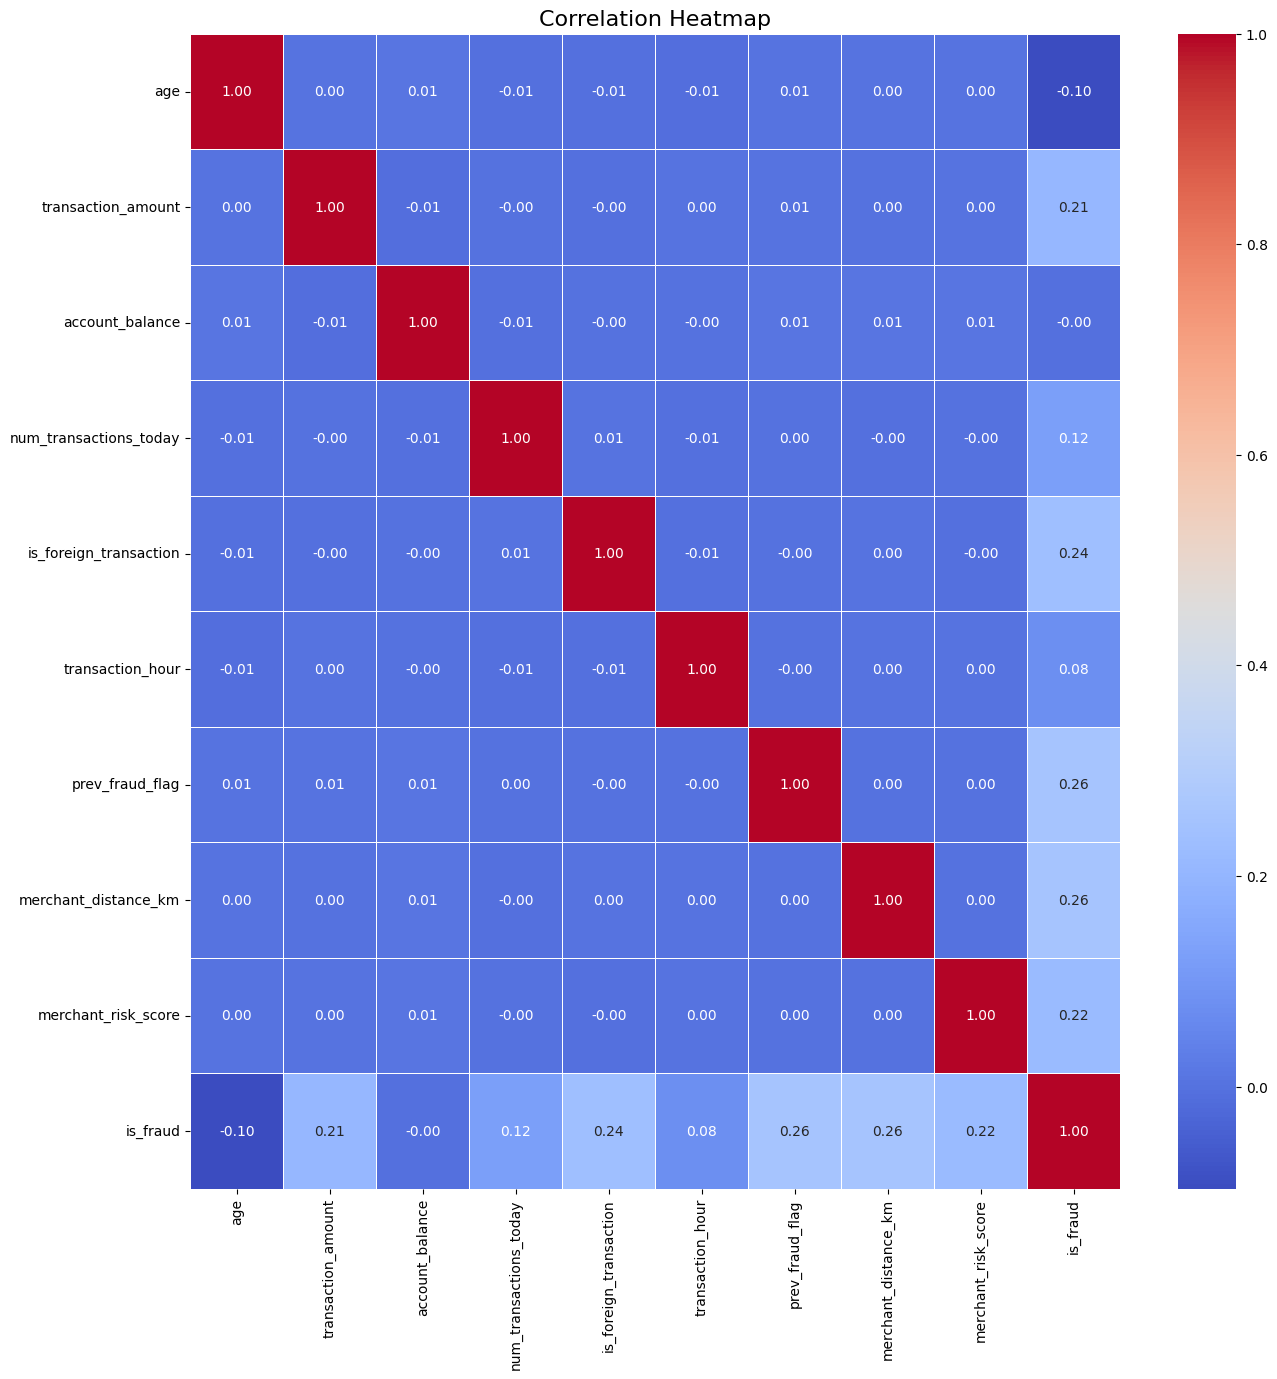

In [ ]:
plt.figure(figsize=(15, 15))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=16)
plt.show()

# Train Test Split

In [ ]:
X = df.drop('is_fraud', axis=1)
y = df['is_fraud']

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 20, stratify=y)   # stratify=y preserves the fraud/genuine ratio in both splits

# Feature Scaling

Each model that benefits from scaling (Logistic Regression, SVC, KNN) is wrapped in a `Pipeline` with a `StandardScaler`, fit only on the training data so there's no leakage from the test set. Tree-based models (Decision Tree, Gradient Boosting, Bagging) don't need scaling, so they are left as plain estimators. `KMeans` has been removed from this comparison since it's unsupervised and scoring it against `is_fraud` with `classification_report` does not produce a meaningful result.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier, BaggingClassifier

models = {
    "LogisticRegression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))
    ]),
    "DecisionTreeClassifier": DecisionTreeClassifier(random_state=20),
    "svcclassifier": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(probability=True, class_weight="balanced"))
    ]),
    "knnclassifier": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", KNeighborsClassifier(n_neighbors=5))
    ]),
    "GradientBoostingClassifier": GradientBoostingClassifier(random_state=20),
    "BaggingClassifier": BaggingClassifier(estimator=KNeighborsClassifier(), n_estimators=20, random_state=20),
}

In [ ]:
from sklearn.metrics import classification_report

for name, model in models.items():
    model.fit(X_train, y_train)

for name, model in models.items():
    y_pred = model.predict(X_test)
    print(f"\nModel: {name}")
    print(classification_report(y_test, y_pred, zero_division=0))


Model: LogisticRegression
              precision    recall  f1-score   support

           0       0.74      0.77      0.75      3318
           1       0.74      0.72      0.73      3083

    accuracy                           0.74      6401
   macro avg       0.74      0.74      0.74      6401
weighted avg       0.74      0.74      0.74      6401


Model: DecisionTreeClassifier
              precision    recall  f1-score   support

           0       0.67      0.66      0.66      3318
           1       0.64      0.65      0.64      3083

    accuracy                           0.65      6401
   macro avg       0.65      0.65      0.65      6401
weighted avg       0.65      0.65      0.65      6401


Model: svcclassifier
              precision    recall  f1-score   support

           0       0.74      0.78      0.76      3318
           1       0.75      0.70      0.72      3083

    accuracy                           0.74      6401
   macro avg       0.74      0.74      0.74     

In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import plotly.express as px

model_results = []

for name, model in models.items():
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    # For ROC AUC we need probabilities; every model above supports predict_proba
    y_proba = model.predict_proba(X_test)[:, 1]
    roc_auc = roc_auc_score(y_test, y_proba)

    model_results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC AUC": roc_auc
    })

results = pd.DataFrame(model_results).sort_values("F1 Score", ascending=False)

fig = px.bar(
    results,
    x="Model",
    y="Accuracy",
    color="Model",
    text="Accuracy",
    title="Model Accuracy Comparison"
)
fig.show()

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,LogisticRegression,0.741603,0.739685,0.715212,0.727243,0.827142
2,svcclassifier,0.741290,0.745950,0.701914,0.723262,0.809377
4,GradientBoostingClassifier,0.738322,0.745296,0.693805,0.718629,0.822665
3,knnclassifier,0.703484,0.700779,0.670775,0.685449,0.765498
1,DecisionTreeClassifier,0.653492,0.638666,0.646124,0.642373,0.653231
5,BaggingClassifier,0.588970,0.577503,0.546221,0.561427,0.616573


# Hyperparameter Tunning

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# defining parameter range
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'random_state': (list(range(1, 20)))
}
model=GradientBoostingClassifier()
grid = RandomizedSearchCV(model, param_grid, refit = True, verbose = 2, scoring='f1_weighted', cv=5)

# fitting the model for grid search
grid.fit(X_train,y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END learning_rate=0.2, max_depth=None, min_samples_leaf=4, min_samples_split=10, n_estimators=200, random_state=3; total time= 1.3min
[CV] END learning_rate=0.2, max_depth=None, min_samples_leaf=4, min_samples_split=10, n_estimators=200, random_state=3; total time= 1.3min
[CV] END learning_rate=0.2, max_depth=None, min_samples_leaf=4, min_samples_split=10, n_estimators=200, random_state=3; total time= 1.3min
[CV] END learning_rate=0.2, max_depth=None, min_samples_leaf=4, min_samples_split=10, n_estimators=200, random_state=3; total time= 1.3min
[CV] END learning_rate=0.2, max_depth=None, min_samples_leaf=4, min_samples_split=10, n_estimators=200, random_state=3; total time= 1.4min
[CV] END learning_rate=0.01, max_depth=5, min_samples_leaf=2, min_samples_split=10, n_estimators=100, random_state=19; total time=   8.6s
[CV] END learning_rate=0.01, max_depth=5, min_samples_leaf=2, min_samples_split=10, n_estimators=100, rand

RandomizedSearchCV(cv=5, estimator=GradientBoostingClassifier(),
                   param_distributions={'learning_rate': [0.01, 0.05, 0.1, 0.2],
                                        'max_depth': [3, 5, 7, None],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300],
                                        'random_state': [1, 2, 3, 4, 5, 6, 7, 8,
                                                         9, 10, 11, 12, 13, 14,
                                                         15, 16, 17, 18, 19]},
                   scoring='f1_weighted', verbose=2)

In [ ]:
print(grid.best_params_)

{'random_state': 4, 'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 7, 'learning_rate': 0.01}


In [ ]:
y_pred_tuned = grid.best_estimator_.predict(X_test)
print(classification_report(y_test, y_pred_tuned, zero_division=0))

              precision    recall  f1-score   support

           0       0.73      0.78      0.76      3318
           1       0.75      0.69      0.72      3083

    accuracy                           0.74      6401
   macro avg       0.74      0.74      0.74      6401
weighted avg       0.74      0.74      0.74      6401



In [ ]:
rom sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_tuned)
fig = px.imshow(
    cm, text_auto=True, x=['Predicted Genuine', 'Predicted Fraud'],
    y=['Actual Genuine', 'Actual Fraud'], color_continuous_scale='Blues',
    title='Confusion Matrix — Tuned Gradient Boosting'
)
fig.show()

In [ ]:
prediction_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_tuned
})

prediction_df

,Actual,Predicted
0,0,0
1,0,0
2,0,0
3,1,1
4,0,0
...,...,...
6396,1,1
6397,1,0
6398,0,1
6399,1,1


# Feature Importance

In [ ]:
importances = pd.Series(
    grid.best_estimator_.feature_importances_, index=X.columns
).sort_values(ascending=False)

fig = px.bar(
    importances[::-1], orientation='h',
    title='Feature Importances — Tuned Gradient Boosting',
    labels={'index': 'Feature', 'value': 'Importance'}
)
fig.show()

# Key Findings

* The dataset contains a **nearly balanced distribution** of genuine and fraudulent transactions, with **51.8% genuine** and **48.2% fraudulent** transactions.
* **Fraudulent transactions tend to have higher transaction amounts** compared with genuine transactions.
* **Account balance** shows considerable overlap between fraud and genuine transactions, so it does not provide strong separation by itself.
* **Age** shows some differences between fraud and genuine transactions, but there is substantial overlap across age groups.
* **Merchant risk score** shows a stronger association with fraudulent transactions, particularly at higher risk levels.
* **Fraud rates vary by transaction hour**, with relatively higher fraud rates observed during several later hours.
* **Foreign transactions show a higher association with fraud** compared with domestic transactions.
* **Merchant distance** varies widely for both classes and shows significant overlap, making it more useful when combined with other features.
* **Previous fraud history is a strong fraud indicator**—transactions with a previous fraud flag contain a much higher proportion of fraudulent transactions.
* Fraudulent transactions have a **higher average number of daily transactions (26.69)** compared with genuine transactions (**23.28**).
* Overall, **transaction amount, merchant risk score, foreign transaction status, previous fraud flag, transaction hour, and transaction frequency** provide useful information for fraud prediction.
* No single feature is sufficient on its own; combining multiple transaction and behavioral features is important for **effective fraud detection**.
* The EDA findings support the use of **Machine Learning classification algorithms** to distinguish fraudulent transactions from genuine transactions.


# Conclusion

The **Credit Card Fraud Detection using Machine Learning** project successfully analyzes transaction patterns and identifies factors associated with fraudulent activities. The EDA revealed that features such as **transaction amount, merchant risk score, transaction hour, foreign transaction status, previous fraud history, and transaction frequency** provide useful information for distinguishing fraudulent transactions from genuine ones. The relatively balanced fraud and genuine classes make the dataset suitable for binary classification. Overall, the project demonstrates how **Machine Learning and data analysis can be effectively applied to detect suspicious credit card transactions and support more secure financial transactions**.
